<a href="https://colab.research.google.com/github/MuhammadAhmedMasood/deep-learning-pytorch/blob/main/04_PyTorch_custom_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn

torch.__version__

'2.11.0+cpu'

In [ ]:
device  = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
# get data: smaller dataset of food101 - 75 training and 25 testing

In [8]:
import requests
import zipfile
from pathlib import Path
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
  print(f"{image_path} directory already exists...skipping download")
else:
  print(f"{image_path} does not exist, creating one...")
  image_path.mkdir(parents=True, exist_ok = True)

with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading pizza, steak, sushi data...")
  f.write(request.content)

with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
  zip_ref.extractall(image_path)

data/pizza_steak_sushi directory already exists...skipping download


In [11]:
import os
def walk_through_dir(dir_path):
  """Walk through dir_path returning its continue..."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [12]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.


In [13]:
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

data/pizza_steak_sushi/test/pizza/2019408.jpg
pizza
random image path: data/pizza_steak_sushi/test/pizza/2019408.jpg
Image class: pizza
Image height: 512
Imag width: 512


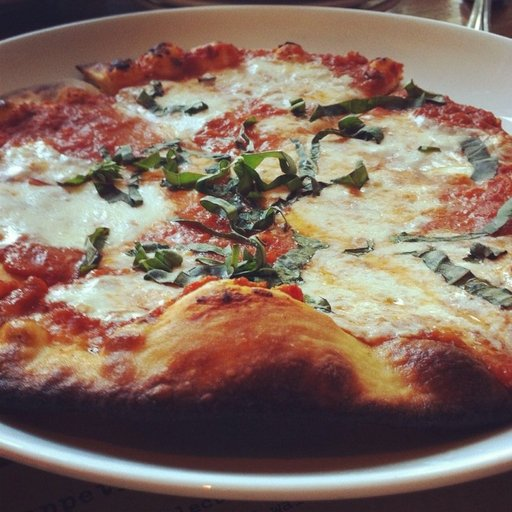

In [25]:
import random
from PIL import Image

random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)
print(random_image_path)
image_class = random_image_path.parent.stem
print(image_class)
img = Image.open(random_image_path)
print(f"random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Imag width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

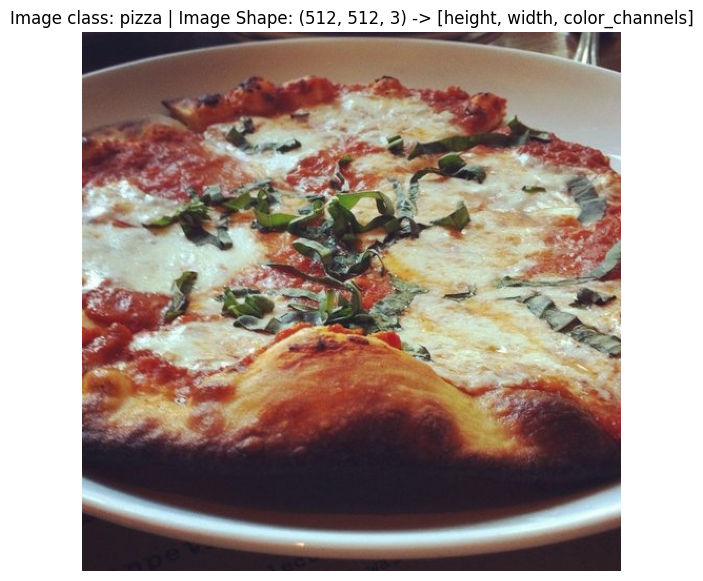

In [26]:
import numpy as np
import matplotlib.pyplot as plt
img_as_array = np.asarray(img)

plt.figure(figsize = (10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image Shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False)

In [28]:
# trasforming data into tensors

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [29]:
# write a transform for image:
data_transform = transforms.Compose([
    transforms.Resize(size = (64,64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor()
])

In [30]:
data_transform(img)

tensor([[[0.2235, 0.1490, 0.2235,  ..., 0.1294, 0.1373, 0.1412],
         [0.2706, 0.1961, 0.2471,  ..., 0.1137, 0.1137, 0.1176],
         [0.3020, 0.2627, 0.3020,  ..., 0.1098, 0.1137, 0.1137],
         ...,
         [0.1647, 0.1647, 0.1686,  ..., 0.1451, 0.1490, 0.1490],
         [0.1725, 0.1686, 0.1686,  ..., 0.1490, 0.1451, 0.1451],
         [0.1765, 0.1765, 0.1725,  ..., 0.1490, 0.1451, 0.1451]],

        [[0.1647, 0.1176, 0.1961,  ..., 0.1137, 0.1176, 0.1216],
         [0.1843, 0.1333, 0.2157,  ..., 0.1059, 0.1059, 0.1098],
         [0.2000, 0.1765, 0.2471,  ..., 0.1059, 0.1020, 0.1020],
         ...,
         [0.1216, 0.1176, 0.1216,  ..., 0.1059, 0.1020, 0.1059],
         [0.1216, 0.1216, 0.1216,  ..., 0.1059, 0.1059, 0.1059],
         [0.1216, 0.1216, 0.1176,  ..., 0.1098, 0.1059, 0.1059]],

        [[0.1961, 0.1647, 0.2392,  ..., 0.1647, 0.1686, 0.1765],
         [0.1922, 0.1647, 0.2431,  ..., 0.1608, 0.1608, 0.1647],
         [0.2039, 0.1882, 0.2667,  ..., 0.1608, 0.1608, 0.

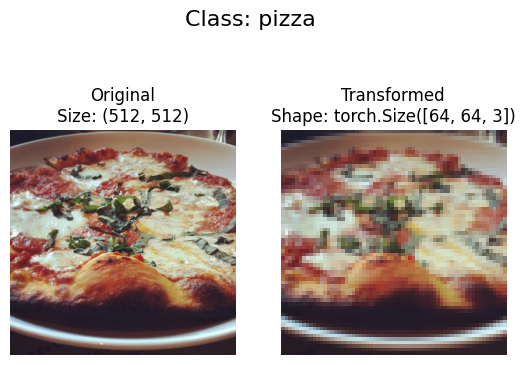

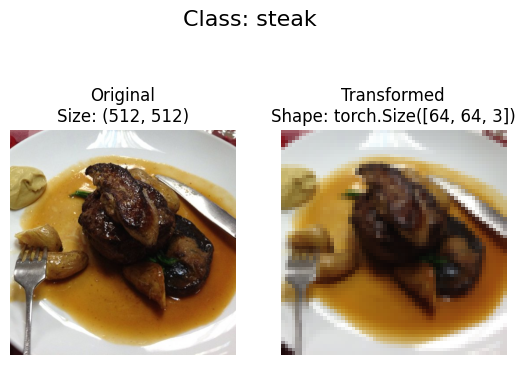

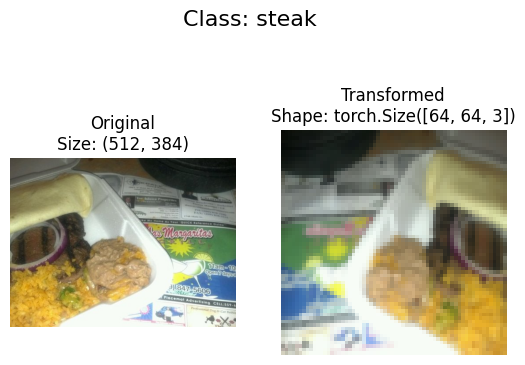

In [33]:
# visualize the tensor:
def plot_transformed_images(image_paths, transform, n = 3, seed = 42):
  """
  Select random images from a path of images and loads/ transforms them then plots
  the original vs the transformed version.
  """
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows = 1, ncols = 2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize: {f.size}")
      ax[0].axis(False)

      transformed_image = transform(f).permute(1,2,0) # (c,H,W) -> (H,W,c)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize = 16)

plot_transformed_images(image_paths = image_path_list, transform = data_transform, n = 3, seed = 42)



